In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [2]:
import pandas as pd
import re

gff_path = '/gale/raidix/rdx-7/jwalker/Kay_Qu/c1038_genes_overlapping_c2952_dmw_chunks.gff'

# 1. Read the GFF (Skipping comment lines starting with '#')
# GFFs are tab-separated and have 9 standard columns
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
df_gff = pd.read_csv(gff_path, sep='\t', comment='#', header=None, names=gff_cols)

# 2. Filter for 'gene' features only (Column 3)
genes_only = df_gff[df_gff['type'] == 'gene'].copy()

# 3. Extract the ID from the 'attributes' column
# Usually looks like: "ID=gene:AT1G01010;Name=..." or "ID=AT1G01010"
def extract_id(attr_string):
    # This regex looks for 'ID=' followed by characters until a semicolon or end of string
    match = re.search(r'ID=([^;]+)', attr_string)
    if match:
        gene_id = match.group(1)
        # Clean up common prefixes like 'gene:' if they exist
        return gene_id.replace('gene:', '')
    return None

# Apply the extraction
new_gene_list = genes_only['attributes'].apply(extract_id).dropna().unique().tolist()

# 4. Update your pipeline variable
hazel_genes = pd.Index(new_gene_list)

print(f"✅ Loaded {len(hazel_genes)} unique Gene IDs from the GFF file.")
print(f"Sample IDs: {new_gene_list[:5]}")

✅ Loaded 1038 unique Gene IDs from the GFF file.
Sample IDs: ['AT1G01300', 'AT1G01770', 'AT1G01780', 'AT1G01830', 'AT1G01950']


In [3]:
# ==========================================
# CELL 3: BUILD UNCOLLAPSED RNA MATRIX
# ==========================================
# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# 2. Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# 3. Normalize to CPM and Log1p transform
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p = np.log1p(rna_cpm)

# 4. Map the fine-grained clusters instead of 'merged_cluster'
# Assuming the single column in your meta file holds the cluster ID (0-16)
meta_col_name = meta.columns[0]
fine_clusters = meta.loc[common_cells, meta_col_name].map(cluster_mapping)
rna_log1p['fine_cluster'] = fine_clusters

# 5. Aggregate by the new fine-grained clusters
uncollapsed_rna_matrix = rna_log1p.groupby('fine_cluster').mean().T
uncollapsed_rna_matrix = uncollapsed_rna_matrix[cluster_order] # Force correct order

print(f"Uncollapsed RNA matrix shape: {uncollapsed_rna_matrix.shape}")


# ==========================================
# CELL 4: BUILD UNCOLLAPSED METHYLATION MATRIX
# ==========================================
# 1. Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

# Map the fine-grained clusters
mCGN_mc['fine_cluster'] = meta[meta_col_name].map(cluster_mapping)
mCGN_cov['fine_cluster'] = meta[meta_col_name].map(cluster_mapping)

# Aggregate counts by fine cluster
cluster_c = mCGN_mc.groupby('fine_cluster').sum().T.reindex(columns=cluster_order)
uncollapsed_cluster_m = mCGN_cov.groupby('fine_cluster').sum().T.reindex(columns=cluster_order)

# 2. Fit Global Offsets (deltas)
global_c = cluster_c.sum(axis=0)
global_m = uncollapsed_cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# 3. Calculate Expected Methylation (p0)
gene_c = cluster_c.sum(axis=1)
gene_m = uncollapsed_cluster_m.sum(axis=1)

valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m_filt = uncollapsed_cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# 4. Extract Adjusted Matrix
obs_p = cluster_c / cluster_m_filt.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

uncollapsed_adj_meth_matrix = obs_p - p0_df

print(f"Uncollapsed Meth Residuals matrix shape: {uncollapsed_adj_meth_matrix.shape}")

Uncollapsed RNA matrix shape: (64507, 17)
Uncollapsed Meth Residuals matrix shape: (32357, 17)


In [6]:
# ==========================================
# REFACTORED COMBINATORIAL HEATMAP SCRIPT
# ==========================================
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
import statsmodels.api as sm
from scipy.stats import zscore
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

teal_rust_cmap = LinearSegmentedColormap.from_list("Teal_Rust", ["#FF8C00", "white", "#004d4d"])
rna_cmap = LinearSegmentedColormap.from_list("Grey_Green", ["white", "forestgreen"])

# Re-assign variables for clean reading
rna_df = uncollapsed_rna_matrix
meth_df = uncollapsed_adj_meth_matrix
weights_df = uncollapsed_cluster_m

# 1. Define the 3 Cluster Dimensions
meso_epi_cols = [c for c in cluster_order if c.endswith('M') or c.endswith('E')]
non_meso_epi_cols = [c for c in cluster_order if c not in meso_epi_cols]

cluster_dims = {
    'all_clusters': cluster_order,
    'meso_epi': meso_epi_cols,
    'non_meso_epi': non_meso_epi_cols
}

# 2. Define the 2 Gene Dimensions
all_metadata_genes = rna_df.index.intersection(meth_df.index)
gene_dims = {
    '30k_genes': all_metadata_genes,
    'hazel_genes': all_metadata_genes.intersection(hazel_genes)
}

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def calculate_wls_stats(genes, subset_cols):
    """Calculates WLS specifically on the selected column subset with R2 and Beta tracking."""
    valid_genes, p_vals, coefs, r2_vals = [], [], [], []
    for gene in genes:
        r_vals = rna_df.loc[gene, subset_cols].values
        m_vals = meth_df.loc[gene, subset_cols].values
        w_vals = weights_df.loc[gene, subset_cols].values
        
        if np.std(r_vals) == 0 or np.std(m_vals) == 0:
            continue
            
        try:
            mod = sm.WLS(zscore(r_vals), sm.add_constant(zscore(m_vals)), weights=w_vals).fit()
            valid_genes.append(gene)
            p_vals.append(mod.pvalues[1])  
            coefs.append(mod.params[1])    # The slope (Beta)
            r2_vals.append(mod.rsquared)   # The R-squared value
        except:
            continue

    stats_df = pd.DataFrame({
        'pval': p_vals, 
        'coef': coefs, 
        'r2': r2_vals
    }, index=valid_genes)
    
    if len(stats_df) > 0:
        stats_df['fdr'] = multipletests(stats_df['pval'], method='fdr_bh')[1]
    
    return stats_df

# Example of how to filter this later:
# strict_wls_genes = stats_df[(stats_df['fdr'] < 0.05) & (stats_df['coef'] < 0) & (stats_df['r2'] > 0.3)].index

def get_clustered_data(genes, cols):
    """Z-scores and hierarchically clusters genes for the target columns."""
    z_meth = meth_df.loc[genes, cols].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    z_rna = rna_df.loc[genes, cols].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth.values), method='ward')
        order = hc.leaves_list(linkage)
        return z_meth.iloc[order], z_rna.iloc[order]
    return z_meth, z_rna


def get_clustered_data_anchored(genes, plot_cols, anchor_cols):
    """
    Z-scores and clusters genes based ONLY on the anchor_cols,
    but outputs the data for all plot_cols to show expansion.
    """
    # 1. Calculate Mean and Std ONLY on the anchor (subset) columns
    # Using ddof=0 to perfectly match scipy.stats.zscore behavior
    meth_mean = meth_df.loc[genes, anchor_cols].mean(axis=1)
    meth_std = meth_df.loc[genes, anchor_cols].std(axis=1, ddof=0).replace(0, 1) 
    
    rna_mean = rna_df.loc[genes, anchor_cols].mean(axis=1)
    rna_std = rna_df.loc[genes, anchor_cols].std(axis=1, ddof=0).replace(0, 1)
    
    # 2. Apply this subset-derived Mean & Std to ALL requested plot columns
    z_meth_plot = meth_df.loc[genes, plot_cols].sub(meth_mean, axis=0).div(meth_std, axis=0).clip(-2.5, 2.5).fillna(0)
    z_rna_plot = rna_df.loc[genes, plot_cols].sub(rna_mean, axis=0).div(rna_std, axis=0).clip(-2.5, 2.5).fillna(0)
    
    # 3. Perform Hierarchical Clustering ONLY on the anchor columns
    z_meth_anchor = z_meth_plot[anchor_cols] 
    
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth_anchor.values), method='ward')
        order = hc.leaves_list(linkage)
        
        # Apply the subset-driven row order to the full dataset
        return z_meth_plot.iloc[order], z_rna_plot.iloc[order]
        
    return z_meth_plot, z_rna_plot

def plot_standalone_heatmap(genes, plot_cols, title, save_path, anchor_cols=None):
    """Generates a standalone 1x2 heatmap, with optional anchoring for Z-scores/clustering."""
    if len(genes) == 0:
        print(f"⚠️ Skipping plot '{title}' - no genes survived filters.")
        return
        
    # Check if we should use the anchored calculation or the standard one
    if anchor_cols is not None:
        m_plot, r_plot = get_clustered_data_anchored(genes, plot_cols, anchor_cols)
    else:
        m_plot, r_plot = get_clustered_data(genes, plot_cols)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Meth Heatmap - Lock vmin and vmax!
    sns.heatmap(m_plot, cmap="coolwarm", center=0, vmin=-2.5, vmax=2.5, 
                ax=axes[0], cbar_kws={'label': 'Meth Z'}, yticklabels=False)
    axes[0].set_title(f"{title}\nMethylation Residuals (n={len(genes)})", fontsize=14, pad=10)
    
    # RNA Heatmap - Lock vmin and vmax!
    sns.heatmap(r_plot, cmap=teal_rust_cmap, vmin=-2.5, vmax=2.5, 
                ax=axes[1], cbar_kws={'label': 'RNA Z'}, yticklabels=False)
    axes[1].set_title(f"{title}\nRNA Expression (n={len(genes)})", fontsize=14, pad=10)

    # Dynamic Formatting & Dividers
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        
        if len(plot_cols) == 17:
            ax.axvline(5, color='black', lw=2, linestyle=':')  
            ax.axvline(10, color='black', lw=2, linestyle=':')
        elif len(plot_cols) == 10:
            ax.axvline(5, color='black', lw=2, linestyle=':')

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close() 
    print(f"✅ Saved: {save_path}")



Calculating standard global WLS...

Total genes with Negative Slope AND R2 > 0.3: 799

--- TOP 10 GENES (No P-value filter applied yet) ---


,coef,r2,pval,fdr
AT4G01130,-0.939587,0.894405,1.012187e-08,0.000106
AT4G18970,-0.951620,0.893417,1.085922e-08,0.000106
AT2G33060,-0.828216,0.888696,1.506467e-08,0.000111
AT1G66100,-1.060066,0.853232,1.220570e-07,0.000718
AT3G26650,-0.945620,0.840921,2.247269e-07,0.000945
AT1G11350,-0.888270,0.837166,2.682223e-07,0.000986
AT1G62030,-0.894577,0.813089,7.640813e-07,0.002498
AT2G34430,-1.180831,0.809658,8.773747e-07,0.002557
AT2G07698,-0.942712,0.806817,9.819966e-07,0.002557
AT2G10940,-0.958572,0.805281,1.042917e-06,0.002557



--- IMPACT OF P-VALUE FILTERS ---
Genes remaining if you add raw p < 0.05: 799 (lost 0)
Genes remaining if you add FDR < 0.05:   53 (lost 746)


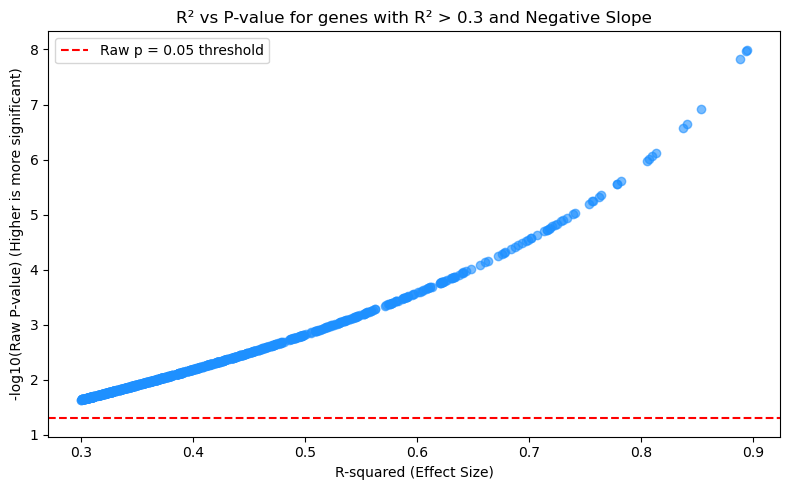

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Run the updated WLS on your "standard condition" (e.g., all 17 clusters, 30k genes)
# Make sure you are using the updated calculate_wls_stats function that returns 'coef' and 'r2'
print("Calculating standard global WLS...")
standard_stats_df = calculate_wls_stats(all_metadata_genes, cluster_order)

# 2. Apply ONLY the Beta and R-squared filters first
base_filtered_df = standard_stats_df[
    (standard_stats_df['coef'] < 0) & 
    (standard_stats_df['r2'] > 0.3)
].copy()

# Sort by R2 to see the strongest correlations at the top
base_filtered_df = base_filtered_df.sort_values('r2', ascending=False)

print(f"\nTotal genes with Negative Slope AND R2 > 0.3: {len(base_filtered_df)}")

# 3. Glimpse the top 10 genes without the p-value filter
print("\n--- TOP 10 GENES (No P-value filter applied yet) ---")
display(base_filtered_df[['coef', 'r2', 'pval', 'fdr']].head(10))

# 4. Check how many of these ALSO pass a raw p < 0.05 or FDR < 0.05
pass_raw_p = base_filtered_df[base_filtered_df['pval'] < 0.05]
pass_fdr = base_filtered_df[base_filtered_df['fdr'] < 0.05]

print(f"\n--- IMPACT OF P-VALUE FILTERS ---")
print(f"Genes remaining if you add raw p < 0.05: {len(pass_raw_p)} (lost {len(base_filtered_df) - len(pass_raw_p)})")
print(f"Genes remaining if you add FDR < 0.05:   {len(pass_fdr)} (lost {len(base_filtered_df) - len(pass_fdr)})")

# 5. Quick visual diagnostic: R-squared vs -log10(P-value)
plt.figure(figsize=(8, 5))
plt.scatter(base_filtered_df['r2'], -np.log10(base_filtered_df['pval']), alpha=0.6, color='dodgerblue')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='Raw p = 0.05 threshold')

plt.title("R² vs P-value for genes with R² > 0.3 and Negative Slope")
plt.xlabel("R-squared (Effect Size)")
plt.ylabel("-log10(Raw P-value) (Higher is more significant)")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
def score_focal_clusters(rna_df, meth_df, weights_df, focal_clusters, 
                         min_cov=10, min_meth_shift=0.05, min_rna_shift=0.5, mode="anti"):
    """
    Compute outlier scores for genes for a focal cluster or cluster group.
    """
    rest_clusters = [c for c in rna_df.columns if c not in focal_clusters]
    results = []

    # THE FIX: Only keep genes that exist in all 3 matrices!
    common_genes = rna_df.index.intersection(meth_df.index).intersection(weights_df.index)

    for gene in common_genes:
        # values
        m_focal = meth_df.loc[gene, focal_clusters].mean()
        m_rest  = meth_df.loc[gene, rest_clusters].values

        r_focal = rna_df.loc[gene, focal_clusters].mean()
        r_rest  = rna_df.loc[gene, rest_clusters].values

        cov_focal = weights_df.loc[gene, focal_clusters].mean()

        # skip low coverage
        if cov_focal < min_cov:
            continue

        # robust stats
        m_med = np.median(m_rest)
        m_mad = mad(m_rest)

        r_med = np.median(r_rest)
        r_mad = mad(r_rest)

        # shifts
        meth_shift = m_focal - m_med
        rna_shift  = r_focal - r_med

        # effect filters
        if abs(meth_shift) < min_meth_shift:
            continue
        if abs(rna_shift) < min_rna_shift:
            continue

        # z-scores
        meth_z = meth_shift / m_mad
        rna_z  = rna_shift / r_mad

        # correlation direction
        corr_product = meth_z * rna_z

        if corr_product < 0:
            corr_type = "anti"
        else:
            corr_type = "positive"

        # filtering by mode
        if mode == "anti" and corr_type != "anti":
            continue
        if mode == "positive" and corr_type != "positive":
            continue

        # scoring
        anti_score = -corr_product
        abs_score  = abs(corr_product)

        results.append({
            'gene': gene,
            'meth_shift': meth_shift,
            'rna_shift': rna_shift,
            'meth_z': meth_z,
            'rna_z': rna_z,
            'corr_type': corr_type,
            'anti_score': anti_score,
            'abs_score': abs_score,
            'coverage': cov_focal
        })

    res = pd.DataFrame(results)

    if len(res) == 0:
        return res

    # sorting depends on mode
    if mode == "anti":
        return res.sort_values('anti_score', ascending=False)
    elif mode == "positive":
        return res.sort_values('anti_score', ascending=True)
    else:
        return res.sort_values('abs_score', ascending=False)

In [15]:
import os

# 1. Dynamically create a focal set for EVERY individual cluster
# This creates a dictionary like: {'Palisade M': ['Palisade M'], 'Epidermis 1E': ['Epidermis 1E'], ...}
all_clusters_focal_sets = {cluster_name: [cluster_name] for cluster_name in cluster_order}

# 2. Set up directories to save the results
csv_save_dir = './outliers/csvs/'
os.makedirs(csv_save_dir, exist_ok=True)

outlier_results_anti = {}
outlier_results_pos = {}

print(f"Running outlier detection across {len(all_clusters_focal_sets)} individual clusters...\n")

# 3. Run the analysis loop
for cluster_name, clusters in all_clusters_focal_sets.items():
    # Clean up the name for file saving (replace spaces with underscores)
    safe_name = cluster_name.replace(" ", "_").replace("/", "_")
    
    # Run Anti-Correlated (The expected biology: Methylation silences RNA here specifically)
    res_anti = score_focal_clusters(rna_df, meth_df, weights_df, clusters, mode="anti")
    outlier_results_anti[cluster_name] = res_anti
    
    if len(res_anti) > 0:
        res_anti.to_csv(os.path.join(csv_save_dir, f"outlier_{safe_name}_anti.csv"), index=False)
        
    # Run Positively Correlated (The control)
    res_pos = score_focal_clusters(rna_df, meth_df, weights_df, clusters, mode="positive")
    outlier_results_pos[cluster_name] = res_pos
    
    if len(res_pos) > 0:
        res_pos.to_csv(os.path.join(csv_save_dir, f"outlier_{safe_name}_pos.csv"), index=False)
        
    print(f"✅ {cluster_name}: Found {len(res_anti)} anti-correlated outliers.")

print("\n🎉 Exhaustive single-cluster outlier analysis complete!")

Running outlier detection across 17 individual clusters...

✅ 3 Early M: Found 5 anti-correlated outliers.
✅ 0 Mid M: Found 7 anti-correlated outliers.
✅ 7 Expanding M: Found 27 anti-correlated outliers.
✅ 1 Late M: Found 18 anti-correlated outliers.
✅ 10 Senescent M: Found 39 anti-correlated outliers.
✅ 5 Early E: Found 4 anti-correlated outliers.
✅ 13 Expanding E: Found 61 anti-correlated outliers.
✅ 4 Abaxial E: Found 18 anti-correlated outliers.
✅ 6 Adaxial E: Found 39 anti-correlated outliers.
✅ 8 Senescent E: Found 44 anti-correlated outliers.
✅ 14 Guard cell: Found 136 anti-correlated outliers.
✅ 2 Vasculature: Found 0 anti-correlated outliers.
✅ 11 PPP: Found 34 anti-correlated outliers.
✅ 9 Phloem: Found 18 anti-correlated outliers.
✅ 16 Myrosinase: Found 93 anti-correlated outliers.
✅ 12 S phase: Found 11 anti-correlated outliers.
✅ 15 G2M phase: Found 70 anti-correlated outliers.

🎉 Exhaustive single-cluster outlier analysis complete!


In [16]:
# 1. Calculate WLS stats specifically for meso_epi clusters and the 30k genes
print("Calculating WLS stats for Meso+Epi (30k genes)...")
stats_df_meso_epi = calculate_wls_stats(all_metadata_genes, meso_epi_cols)

# 2. Extract the Top 300 genes based strictly on lowest FDR
top_300_df = stats_df_meso_epi.sort_values('fdr').head(300)

# 3. Split the Top 300 into Positive and Negative Correlation based on 'coef'
negative_genes = top_300_df[top_300_df['coef'] < 0].index.tolist()
positive_genes = top_300_df[top_300_df['coef'] > 0].index.tolist()

# 4. Print the summary counts
print("\n--- RESULTS FOR: WLS on Meso+Epi | 30k genes | Top 300 FDR ---")
print(f"Total NEGATIVE correlation (Repressed by Meth): {len(negative_genes)}")
print(f"Total POSITIVE correlation (Activated by Meth): {len(positive_genes)}")

# 5. Glimpse the lists (First 15 of each)
print("\nTop Negative Genes (Sample):")
print(negative_genes[:15])

print("\nTop Positive Genes (Sample):")
print(positive_genes[:15])



Calculating WLS stats for Meso+Epi (30k genes)...

--- RESULTS FOR: WLS on Meso+Epi | 30k genes | Top 300 FDR ---
Total NEGATIVE correlation (Repressed by Meth): 182
Total POSITIVE correlation (Activated by Meth): 118

Top Negative Genes (Sample):
['AT4G18970', 'AT2G33060', 'AT2G08300', 'AT4G30400', 'AT3G14420', 'AT5G09660', 'AT4G01130', 'AT3G26650', 'AT1G66100', 'AT3G14415', 'AT3G55630', 'AT4G04265', 'AT4G15630', 'AT1G01500', 'AT4G36648']

Top Positive Genes (Sample):
['AT5G50180', 'AT1G06103', 'AT4G02900', 'AT5G51670', 'AT3G05285', 'AT4G27330', 'AT5G64030', 'AT4G33650', 'AT4G00630', 'AT1G02305', 'AT5G06925', 'AT5G24970', 'AT4G20070', 'AT4G34975', 'AT1G08787']


In [17]:
stats_df_meso_epi

,pval,coef,r2,fdr
AT1G01010,0.584462,-0.213006,0.039000,0.927532
AT1G01020,0.821480,-0.101051,0.006751,0.973319
AT1G01030,0.574262,-0.231848,0.041110,0.924611
AT1G01040,0.150357,0.567687,0.240273,0.750789
AT1G01050,0.528349,0.294782,0.051503,0.913365
...,...,...,...,...
AT5G67600,0.017561,0.696756,0.526322,0.533379
AT5G67610,0.261382,0.439880,0.154364,0.814584
AT5G67620,0.842882,-0.066438,0.005213,0.975850
AT5G67630,0.459689,0.278175,0.070118,0.892499


In [21]:
# Optional: Save these lists to simple text files for your records
with open('./genes/meso_epi_30k_top300_negative.txt', 'w') as f:
    f.write('\n'.join(negative_genes))

with open('./genes/meso_epi_30k_top300_positive.txt', 'w') as f:
    f.write('\n'.join(positive_genes))
print("\n✅ Saved full lists to text files in the current directory.")


✅ Saved full lists to text files in the current directory.


In [20]:
pwd

'/ceph/MethDev/pbio/kay/2026'

In [22]:
import os

# 1. Extract the list of 799 genes from your filtered dataframe
target_genes_799 = base_filtered_df.index.tolist()

# 2. Define where to save the image
save_dir = './figures/heatmaps_refined/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'global_wls_negative_r2_filtered.png')

# 3. Generate the heatmap
print(f"Clustering and plotting {len(target_genes_799)} genes... (this might take a few seconds)")

plot_standalone_heatmap(
    genes=target_genes_799, 
    plot_cols=cluster_order,                # Plot across all 17 columns
    title="Global WLS Repressors\n(Negative Slope, R² > 0.3)", 
    save_path=save_path
    # No anchor_cols needed here, because we are plotting all columns 
    # based on WLS run on all columns!
)

print(f"✅ Heatmap successfully saved to: {save_path}")

Clustering and plotting 799 genes... (this might take a few seconds)
✅ Saved: ./figures/heatmaps_refined/global_wls_negative_r2_filtered.png
✅ Heatmap successfully saved to: ./figures/heatmaps_refined/global_wls_negative_r2_filtered.png


In [10]:
def mad(x):
    return np.median(np.abs(x - np.median(x))) + 1e-6

def score_focal_clusters(rna_df, meth_df, weights_df, focal_clusters, 
                         min_cov=10, min_meth_shift=0.05, min_rna_shift=0.5, mode="anti"):
    """
    Compute outlier scores for genes for a focal cluster or cluster group using robust MAD stats.
    mode: "anti", "positive", or "both"
    """
    rest_clusters = [c for c in rna_df.columns if c not in focal_clusters]
    results = []

    for gene in rna_df.index:
        m_focal = meth_df.loc[gene, focal_clusters].mean()
        m_rest  = meth_df.loc[gene, rest_clusters].values
        r_focal = rna_df.loc[gene, focal_clusters].mean()
        r_rest  = rna_df.loc[gene, rest_clusters].values
        cov_focal = weights_df.loc[gene, focal_clusters].mean()

        if cov_focal < min_cov:
            continue

        # Robust stats
        m_med, m_mad = np.median(m_rest), mad(m_rest)
        r_med, r_mad = np.median(r_rest), mad(r_rest)

        # Shifts
        meth_shift = m_focal - m_med
        rna_shift  = r_focal - r_med

        if abs(meth_shift) < min_meth_shift or abs(rna_shift) < min_rna_shift:
            continue

        # Z-scores based on MAD
        meth_z = meth_shift / m_mad
        rna_z  = rna_shift / r_mad

        corr_product = meth_z * rna_z
        corr_type = "anti" if corr_product < 0 else "positive"

        # Filter by requested mode
        if mode == "anti" and corr_type != "anti": continue
        if mode == "positive" and corr_type != "positive": continue

        results.append({
            'gene': gene,
            'meth_shift': meth_shift, 'rna_shift': rna_shift,
            'meth_z': meth_z, 'rna_z': rna_z,
            'corr_type': corr_type,
            'anti_score': -corr_product,
            'abs_score': abs(corr_product),
            'coverage': cov_focal
        })

    res = pd.DataFrame(results)
    if len(res) == 0: return res

    if mode == "anti":
        return res.sort_values('anti_score', ascending=False)
    elif mode == "positive":
        return res.sort_values('anti_score', ascending=True) # Lowest anti-score is highest positive score
    else:
        return res.sort_values('abs_score', ascending=False)

# ==========================================
# RUNNING THE OUTLIER PIPELINE
# ==========================================
# TODO: Update these with your ACTUAL column names from cluster_order!
focal_sets = {
    'epidermis_example': ['Epidermis 1E', 'Epidermis 2E'], 
    'mesophyll_example': ['Palisade M', 'Spongy M']
}

outlier_results_anti = {}
outlier_results_pos = {}

for name, clusters in focal_sets.items():
    # 1. Get Anti-Correlated (The expected biology)
    res_anti = score_focal_clusters(rna_df, meth_df, weights_df, clusters, mode="anti")
    outlier_results_anti[name] = res_anti
    if len(res_anti) > 0:
        res_anti.to_csv(f"./outlier_{name}_anti.csv", index=False)
    print(f"{name}: {len(res_anti)} anti-correlated genes found.")
    
    # 2. Get Positively Correlated (The control)
    res_pos = score_focal_clusters(rna_df, meth_df, weights_df, clusters, mode="positive")
    outlier_results_pos[name] = res_pos
    if len(res_pos) > 0:
        res_pos.to_csv(f"./outlier_{name}_positive.csv", index=False)

KeyError: "None of [Index(['Epidermis 1E', 'Epidermis 2E'], dtype='object', name='fine_cluster')] are in the [index]"

In [9]:
strict_wls_genes = stats_df[(stats_df['fdr'] < 0.05) & (stats_df['coef'] < 0) & (stats_df['r2'] > 0.3)].index

NameError: name 'stats_df' is not defined

In [5]:
# ==========================================
# EXECUTE COMBINATORIAL PIPELINE
# ==========================================

save_dir = './figures/heatmaps_combinatorial/'

for c_name, c_cols in cluster_dims.items():
    for g_name, g_subset in gene_dims.items():
        
        # 1. Run WLS using ONLY the current cluster subset
        stats_df = calculate_wls_stats(g_subset, c_cols)
        
        if len(stats_df) == 0:
            print(f"⚠️ No valid WLS results for {c_name} x {g_name}. Skipping...")
            continue
            
        # 2. Extract Genes based on the 2 Filtering Logics
        filter_outputs = {
            'fdr_less_0.05': stats_df[stats_df['fdr'] < 0.05].index,
            'wls_top_300': stats_df.sort_values('fdr').head(300).index
        }
        
        # 3. Generate the Plots
        for f_name, filtered_genes in filter_outputs.items():
            
            base_filename = f"{c_name}_{g_name}_{f_name}"
            base_title = f"WLS on {c_name} | {g_name} | {f_name}"
            
# Condition A: Plot the genes using the specific cluster subset (No anchor needed)
            plot_standalone_heatmap(
                genes=filtered_genes, 
                plot_cols=c_cols, 
                title=f"{base_title}\n(Plotted on {c_name} columns)", 
                save_path=os.path.join(save_dir, f"{base_filename}_target_cols.png")
            )
            
            # Condition B: Expand to all 17 columns, but ANCHOR to the subset
            if c_name != 'all_clusters':
                plot_standalone_heatmap(
                    genes=filtered_genes, 
                    plot_cols=cluster_order, # The 17 columns to plot
                    title=f"{base_title}\n(Expanded to ALL 17 columns)", 
                    save_path=os.path.join(save_dir, f"{base_filename}_expanded.png"),
                    anchor_cols=c_cols       # Tell the function to anchor math to the subset!
                )

print("\n🎉 Pipeline complete! All combinatorial heatmaps generated.")

KeyboardInterrupt: 